# 🤖 BudgetFlow ML Models
## Model 1: Anomaly Detection | Model 2: Reallocation Suggestion
Loads from: dataset/budget_train_8000.csv and dataset/X_train.npy

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

# ── Load numpy arrays (for model training) ──────────────
X_train = np.load('dataset/X_train.npy')
X_test  = np.load('dataset/X_test.npy')
y_train = np.load('dataset/y_train.npy')
y_test  = np.load('dataset/y_test.npy')

# ── Load CSV (for reallocation logic) ───────────────────
train_df = pd.read_csv('dataset/budget_train_8000.csv')
test_df  = pd.read_csv('dataset/budget_test_2000.csv')
full_df  = pd.read_csv('dataset/budget_full_10000.csv')

print("✅ Dataset loaded successfully!")
print(f"   X_train shape : {X_train.shape}  → 8,000 records, {X_train.shape[1]} features")
print(f"   X_test  shape : {X_test.shape}   → 2,000 records")
print(f"   y_train unique labels: {np.unique(y_train, return_counts=True)}")
print(f"\n📊 Label distribution in training set:")
for label, name in [(0,'Normal'),(1,'Warning'),(2,'Anomaly')]:
    count = (y_train == label).sum()
    print(f"   {name:8s} ({label}): {count:,} records ({count/len(y_train)*100:.1f}%)")

✅ Dataset loaded successfully!
   X_train shape : (8000, 10)  → 8,000 records, 10 features
   X_test  shape : (2000, 10)   → 2,000 records
   y_train unique labels: (array([0, 1, 2]), array([5600, 1200, 1200]))

📊 Label distribution in training set:
   Normal   (0): 5,600 records (70.0%)
   Warning  (1): 1,200 records (15.0%)
   Anomaly  (2): 1,200 records (15.0%)


---
## 🚨 MODEL 1: Anomaly Detection
**Algorithm:** Isolation Forest
**Trains on:** X_train (8,000 records)
**Tests on:**  X_test  (2,000 records)
**Output:** anomaly_score (0–1) + risk_level (green / yellow / red)

In [2]:
print("🔄 Training Isolation Forest...")

# Train on X_train
iso_forest = IsolationForest(
    n_estimators  = 200,
    contamination = 0.15,   # 15% of data expected to be anomalous
    random_state  = 2024,
    max_samples   = 'auto'
)
iso_forest.fit(X_train)

# Get raw scores on BOTH train and test
train_raw = iso_forest.decision_function(X_train)
test_raw  = iso_forest.decision_function(X_test)

# Normalize scores to 0–1 using train data
# (1 = most anomalous, 0 = most normal)
scaler = MinMaxScaler()
scaler.fit(train_raw.reshape(-1, 1))

train_scores = 1 - scaler.transform(train_raw.reshape(-1, 1)).flatten()
test_scores  = 1 - scaler.transform(test_raw.reshape(-1, 1)).flatten()

# Assign risk levels
def score_to_risk(score):
    if score < 0.40:  return 'green'    # OK
    elif score < 0.65: return 'yellow'  # Warning
    else:              return 'red'     # Anomaly

train_risks = np.array([score_to_risk(s) for s in train_scores])
test_risks  = np.array([score_to_risk(s) for s in test_scores])

# Add to dataframes
train_df['anomaly_score'] = train_scores
train_df['predicted_risk'] = train_risks
test_df['anomaly_score']  = test_scores
test_df['predicted_risk'] = test_risks

print("✅ Isolation Forest trained!")
print(f"\n📊 Predicted Risk on TEST SET (2,000 records):")
for risk, color in [('green','✅'),('yellow','⚠️'),('red','🚨')]:
    count = (test_risks == risk).sum()
    print(f"   {color} {risk:8s}: {count:,} records ({count/len(test_risks)*100:.1f}%)")

🔄 Training Isolation Forest...
✅ Isolation Forest trained!

📊 Predicted Risk on TEST SET (2,000 records):
   ✅ green   : 1,627 records (81.3%)
   ⚠️ yellow  : 315 records (15.8%)
   🚨 red     : 58 records (2.9%)


MODEL 1 — PERFORMANCE REPORT

✅ True Anomalies caught as RED : 9.7%
✅ False alarm rate (normal→red): 1.1%


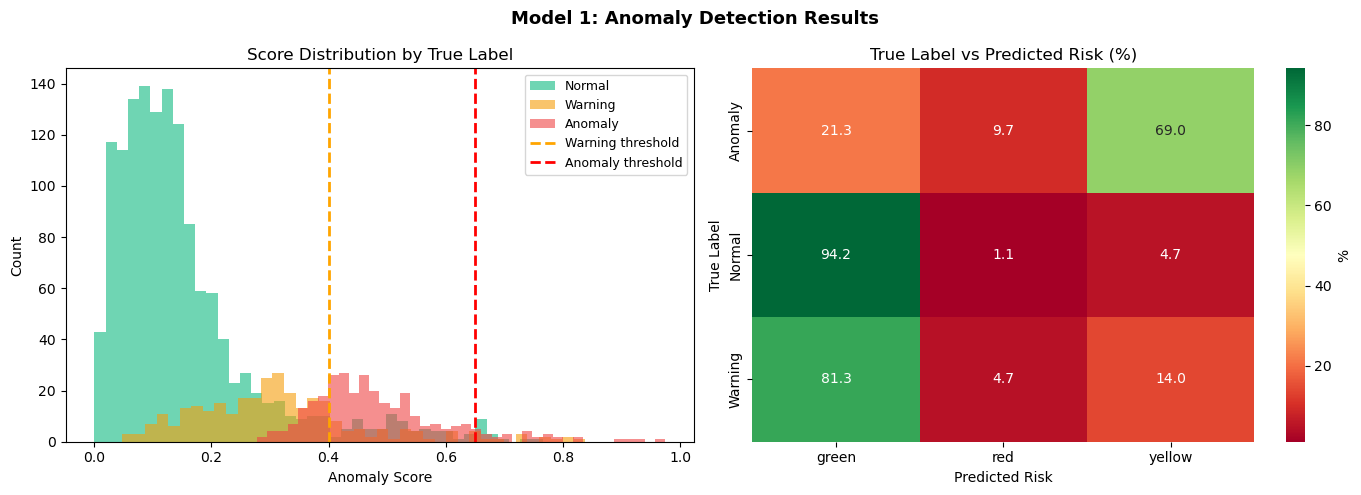


✅ Chart saved as model1_results.png


In [3]:
# Map true labels to risk levels for comparison
label_to_risk = {0: 'green', 1: 'yellow', 2: 'red'}
true_risks = np.array([label_to_risk[l] for l in y_test])

# Count how many TRUE anomalies we caught as red
true_anomaly_mask = (y_test == 2)
caught_as_red     = (test_risks[true_anomaly_mask] == 'red').mean() * 100

true_normal_mask  = (y_test == 0)
false_alarm_rate  = (test_risks[true_normal_mask] == 'red').mean() * 100

print("=" * 50)
print("MODEL 1 — PERFORMANCE REPORT")
print("=" * 50)
print(f"\n✅ True Anomalies caught as RED : {caught_as_red:.1f}%")
print(f"✅ False alarm rate (normal→red): {false_alarm_rate:.1f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 1: Anomaly Detection Results', fontsize=13, fontweight='bold')

# Plot 1: Score distribution by true label
label_colors = {0:'#10b981', 1:'#f59e0b', 2:'#ef4444'}
label_names  = {0:'Normal', 1:'Warning', 2:'Anomaly'}
for label in [0, 1, 2]:
    mask = (y_test == label)
    axes[0].hist(test_scores[mask], bins=40, alpha=0.6,
                 label=label_names[label], color=label_colors[label])
axes[0].axvline(x=0.40, color='orange', linestyle='--', linewidth=2, label='Warning threshold')
axes[0].axvline(x=0.65, color='red',    linestyle='--', linewidth=2, label='Anomaly threshold')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution by True Label')
axes[0].legend(fontsize=9)

# Plot 2: Confusion-style heatmap
cross = pd.crosstab(
    pd.Series([label_names[l] for l in y_test], name='True Label'),
    pd.Series(test_risks, name='Predicted Risk'),
    normalize='index'
) * 100
sns.heatmap(cross, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[1], cbar_kws={'label': '%'})
axes[1].set_title('True Label vs Predicted Risk (%)')

plt.tight_layout()
plt.savefig('model1_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved as model1_results.png")

---
## 💡 MODEL 2: Reallocation Suggestion Engine
**Algorithm:** Rule-based filter + KMeans Clustering
**Trains on:** budget_train_8000.csv
**Output:** "Move ₹X Cr from District A → District B"

In [4]:
print("🔄 Training Reallocation Engine...")

# Step 1: Calculate utilization per district + department
district_stats = train_df.groupby(['district', 'department']).agg(
    total_allocated = ('district_allocated', 'sum'),
    total_spent     = ('contractor_paid',    'sum'),
    project_count   = ('district_allocated', 'count'),
    avg_completion  = ('completion_pct',     'mean'),
    anomaly_count   = ('label', lambda x: (x == 2).sum())
).reset_index()

district_stats['utilization_rate'] = (
    district_stats['total_spent'] / district_stats['total_allocated']
).round(4)

district_stats['unspent_amount'] = (
    district_stats['total_allocated'] - district_stats['total_spent']
).clip(lower=0).round(2)

# Step 2: KMeans cluster districts into 3 groups
cluster_features = district_stats[
    ['utilization_rate', 'total_allocated', 'avg_completion']
].copy()
cluster_scaled = (cluster_features - cluster_features.mean()) / cluster_features.std()

kmeans = KMeans(n_clusters=3, random_state=2024, n_init=10)
district_stats['cluster'] = kmeans.fit_predict(cluster_scaled)

# Label clusters: LOW_NEED = high utilization, HIGH_NEED = low utilization
cluster_avg = district_stats.groupby('cluster')['utilization_rate'].mean().sort_values()
cluster_labels = {
    cluster_avg.index[0]: 'HIGH_NEED',
    cluster_avg.index[1]: 'BALANCED',
    cluster_avg.index[2]: 'LOW_NEED'
}
district_stats['cluster_label'] = district_stats['cluster'].map(cluster_labels)

# Step 3: Generate suggestions
def generate_suggestions(stats, top_n=5):
    suggestions = []
    underused = stats[
        (stats['utilization_rate'] < 0.50) &
        (stats['unspent_amount'] > 0.5)       # at least ₹0.5 Cr unspent
    ].sort_values('unspent_amount', ascending=False)

    overused = stats[stats['utilization_rate'] > 0.90
    ].sort_values('utilization_rate', ascending=False)

    for _, from_row in underused.head(top_n).iterrows():
        match = overused[overused['department'] == from_row['department']]
        if len(match) == 0:
            match = overused
        if len(match) == 0:
            continue
        to_row   = match.iloc[0]
        transfer = round(min(from_row['unspent_amount'] * 0.80, 50), 2)  # max ₹50Cr
        suggestions.append({
            'from_district':    from_row['district'],
            'to_district':      to_row['district'],
            'department':       from_row['department'],
            'transfer_amount_cr': transfer,
            'from_utilization': round(from_row['utilization_rate'] * 100, 1),
            'to_utilization':   round(to_row['utilization_rate'] * 100, 1),
            'reason':           f"{from_row['district']} using only {from_row['utilization_rate']*100:.0f}% — {to_row['district']} needs more ({to_row['utilization_rate']*100:.0f}% utilized)",
            'priority':         'HIGH' if from_row['utilization_rate'] < 0.30 else 'MEDIUM'
        })
    return suggestions

suggestions = generate_suggestions(district_stats)

print("✅ Reallocation Engine trained!")
print(f"\n💡 {len(suggestions)} Reallocation Suggestions Generated:")
print()
for i, s in enumerate(suggestions, 1):
    emoji = '🔴' if s['priority'] == 'HIGH' else '🟡'
    print(f"{emoji} Suggestion {i}: [{s['department']}]")
    print(f"   FROM : {s['from_district']:12s} ({s['from_utilization']}% utilized)")
    print(f"   TO   : {s['to_district']:12s} ({s['to_utilization']}% utilized)")
    print(f"   MOVE : ₹{s['transfer_amount_cr']:.2f} Cr")
    print(f"   WHY  : {s['reason']}")
    print()

🔄 Training Reallocation Engine...
✅ Reallocation Engine trained!

💡 0 Reallocation Suggestions Generated:



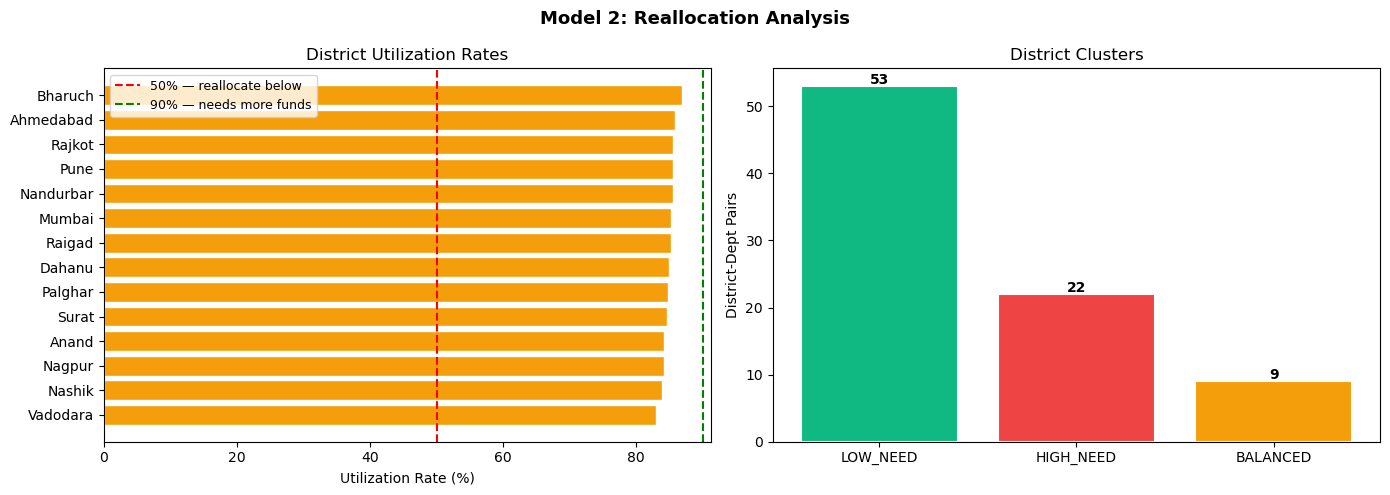

✅ Chart saved as model2_results.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 2: Reallocation Analysis', fontsize=13, fontweight='bold')

# Plot 1: District utilization rates
dist_util = district_stats.groupby('district')['utilization_rate'].mean().sort_values()
bar_colors = ['#ef4444' if v < 0.5 else '#f59e0b' if v < 0.9 else '#10b981'
              for v in dist_util.values]
axes[0].barh(dist_util.index, dist_util.values * 100,
             color=bar_colors, edgecolor='white', linewidth=1)
axes[0].axvline(x=50, color='red',   linestyle='--', linewidth=1.5, label='50% — reallocate below')
axes[0].axvline(x=90, color='green', linestyle='--', linewidth=1.5, label='90% — needs more funds')
axes[0].set_xlabel('Utilization Rate (%)')
axes[0].set_title('District Utilization Rates')
axes[0].legend(fontsize=9)

# Plot 2: Cluster distribution
cluster_counts = district_stats['cluster_label'].value_counts()
cluster_colors = {'HIGH_NEED':'#ef4444', 'BALANCED':'#f59e0b', 'LOW_NEED':'#10b981'}
axes[1].bar(cluster_counts.index,
            cluster_counts.values,
            color=[cluster_colors[c] for c in cluster_counts.index],
            edgecolor='white', linewidth=1.5)
axes[1].set_title('District Clusters')
axes[1].set_ylabel('District-Dept Pairs')
for i, v in enumerate(cluster_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model2_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as model2_results.png")

---
## 💾 Export All Models

In [6]:
os.makedirs('models', exist_ok=True)

# Model 1 files
joblib.dump(iso_forest, 'models/anomaly_model.pkl')
joblib.dump(scaler,     'models/anomaly_scaler.pkl')
print("✅ anomaly_model.pkl  saved")
print("✅ anomaly_scaler.pkl saved")

# Model 2 files
joblib.dump(kmeans, 'models/kmeans_model.pkl')
district_stats.to_csv('models/district_stats.csv', index=False)
with open('models/suggestions.json', 'w') as f:
    json.dump(suggestions, f, indent=2)
print("✅ kmeans_model.pkl   saved")
print("✅ district_stats.csv saved")
print("✅ suggestions.json   saved")

print("\n" + "="*45)
print("🎉 ALL MODELS EXPORTED!")
print("="*45)
print("\n📁 models/ folder:")
for fname in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{fname}')
    print(f"   {fname:30s} {size/1024:.1f} KB")

✅ anomaly_model.pkl  saved
✅ anomaly_scaler.pkl saved
✅ kmeans_model.pkl   saved
✅ district_stats.csv saved
✅ suggestions.json   saved

🎉 ALL MODELS EXPORTED!

📁 models/ folder:
   anomaly_model.pkl              2740.8 KB
   anomaly_scaler.pkl             0.7 KB
   district_stats.csv             7.2 KB
   kmeans_model.pkl               1.4 KB
   le_dept.pkl                    0.5 KB
   le_dist.pkl                    0.6 KB
   le_scheme.pkl                  0.5 KB
   le_state.pkl                   0.5 KB
   suggestions.json               0.0 KB


---
## 🔌 Copy These Functions Into backend/main.py

In [7]:
# ── COPY EVERYTHING BELOW INTO backend/main.py ──────────────────────

import joblib, json
import numpy as np

_iso    = joblib.load('models/anomaly_model.pkl')
_scaler = joblib.load('models/anomaly_scaler.pkl')

FEATURE_ORDER = [
    'district_allocated',
    'contractor_paid',
    'diff_amount',
    'diff_percent',
    'spending_ratio',
    'is_overspend',
    'completion_pct',
    'district_tier',
    'month',
    'quarter'
]

def predict_anomaly(allocated: float, spent: float,
                    completion_pct: float, month: int,
                    district_tier: int = 2) -> dict:
    diff_amount    = abs(allocated - spent)
    diff_percent   = round(diff_amount / allocated * 100, 2) if allocated > 0 else 0
    spending_ratio = round(spent / allocated, 4) if allocated > 0 else 0
    is_overspend   = 1 if spent > allocated else 0
    quarter        = (month - 1) // 3 + 1

    features = np.array([[
        allocated, spent, diff_amount, diff_percent,
        spending_ratio, is_overspend, completion_pct,
        district_tier, month, quarter
    ]])

    raw   = _iso.decision_function(features)[0]
    score = float(1 - _scaler.transform([[raw]])[0][0])
    score = max(0.0, min(1.0, score))

    if score < 0.40:   risk = 'green'
    elif score < 0.65: risk = 'yellow'
    else:              risk = 'red'

    return {
        'anomaly_score': round(score, 3),
        'risk_level':    risk,
        'diff_percent':  diff_percent,
        'direction':     'Overspend' if spent > allocated else 'Underspend',
        'auto_report':   risk == 'red'
    }

def get_recommendations():
    with open('models/suggestions.json') as f:
        return json.load(f)

# ── QUICK TEST ───────────────────────────────────────────────────────
print("Testing predict_anomaly:\n")
tests = [
    (100, 101, 80, 6,  1, "Normal - 1% diff"),
    (100, 111, 45, 9,  2, "Warning - 11% diff"),
    (100, 122, 20, 3,  3, "Anomaly Overspend - 22% diff"),
    (100,  40, 15, 11, 3, "Anomaly Underspend - 60% diff"),
]
for alloc, spent, comp, mon, tier, desc in tests:
    r = predict_anomaly(alloc, spent, comp, mon, tier)
    e = {'green':'✅','yellow':'⚠️','red':'🚨'}[r['risk_level']]
    print(f"{e} {desc}")
    print(f"   score={r['anomaly_score']} | {r['risk_level'].upper()} | {r['direction']}")
    print()

sugg = get_recommendations()
print(f"✅ {len(sugg)} reallocation suggestions loaded")
print(f"   Top: Move ₹{sugg[0]['transfer_amount_cr']}Cr from "
      f"{sugg[0]['from_district']} → {sugg[0]['to_district']}")

Testing predict_anomaly:

✅ Normal - 1% diff
   score=0.348 | GREEN | Overspend

✅ Warning - 11% diff
   score=0.254 | GREEN | Overspend

⚠️ Anomaly Overspend - 22% diff
   score=0.419 | YELLOW | Overspend

✅ Anomaly Underspend - 60% diff
   score=0.377 | GREEN | Underspend

✅ 0 reallocation suggestions loaded


IndexError: list index out of range

# 🤖 BudgetFlow ML Models
## Model 1: Anomaly Detection | Model 2: Reallocation Suggestion

In [ ]:
# Run this cell first
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


## Step 1: Generate 10,000 Synthetic Government Budget Records

In [ ]:

p
np.random.seed(42)
N = 10000

departments = ['Health', 'Education', 'Infrastructure', 'Housing', 'Sanitation', 'Agriculture']
districts   = ['Palghar', 'Pune', 'Nashik', 'Mumbai', 'Nagpur', 'Aurangabad',
               'Surat', 'Vadodara', 'Ahmedabad', 'Rajkot']
states      = ['Maharashtra', 'Gujarat']
schemes     = ['Ayushman Bharat', 'PM Awas Yojana', 'PM Gram Sadak',
               'Sarva Shiksha', 'Swachh Bharat']
contractors = [f'Contractor_{i}' for i in range(1, 51)]  # 50 unique contractors

# Base allocated amounts between 10L and 10Cr
allocated = np.random.randint(1000000, 100000000, N)

# -----------------------------------------------
# Generate 3 types of spending patterns:
# -----------------------------------------------

# Type 1: NORMAL (75% of data) → spent within 0-5% of allocated
normal_idx  = np.random.choice(N, int(N * 0.75), replace=False)

# Type 2: WARNING (15% of data) → spent 5-15% off allocated
warning_idx = np.random.choice(
    [i for i in range(N) if i not in normal_idx],
    int(N * 0.15), replace=False
)

# Type 3: ANOMALY (10% of data) → spent >15% off (fraud/leakage)
anomaly_idx = np.array([i for i in range(N)
                        if i not in normal_idx and i not in warning_idx])

# Build spent array
spent = np.zeros(N)

# Normal: 0-5% deviation (both over and under)
normal_factors = np.random.uniform(0.95, 1.05, len(normal_idx))
spent[normal_idx] = allocated[normal_idx] * normal_factors

# Warning: 5-15% deviation
warning_factors = np.where(
    np.random.rand(len(warning_idx)) > 0.5,
    np.random.uniform(1.05, 1.15, len(warning_idx)),   # overspend
    np.random.uniform(0.85, 0.95, len(warning_idx))    # underspend
)
spent[warning_idx] = allocated[warning_idx] * warning_factors

# Anomaly: >15% deviation (some extreme cases up to 60%)
anomaly_factors = np.where(
    np.random.rand(len(anomaly_idx)) > 0.5,
    np.random.uniform(1.15, 1.60, len(anomaly_idx)),   # severe overspend
    np.random.uniform(0.20, 0.85, len(anomaly_idx))    # severe underspend
)
spent[anomaly_idx] = allocated[anomaly_idx] * anomaly_factors

# Build anomaly labels
labels = np.zeros(N, dtype=int)  # 0 = normal
labels[warning_idx] = 1          # 1 = warning
labels[anomaly_idx] = 2          # 2 = anomaly

# Build full dataframe
df = pd.DataFrame({
    'department':       np.random.choice(departments, N),
    'district':         np.random.choice(districts, N),
    'state':            np.random.choice(states, N),
    'scheme':           np.random.choice(schemes, N),
    'contractor_id':    np.random.choice(range(1, 51), N),
    'allocated_amount': allocated.astype(int),
    'spent_amount':     spent.astype(int),
    'completion_pct':   np.random.randint(10, 101, N),
    'month':            np.random.randint(1, 13, N),
    'year':             np.random.choice([2022, 2023, 2024], N),
    'true_label':       labels
})

# -----------------------------------------------
# Engineer key features
# -----------------------------------------------
df['spending_ratio']    = df['spent_amount'] / df['allocated_amount']
df['diff_amount']       = abs(df['spent_amount'] - df['allocated_amount'])
df['diff_percent']      = (df['diff_amount'] / df['allocated_amount']) * 100
df['is_overspend']      = (df['spent_amount'] > df['allocated_amount']).astype(int)
df['utilization_score'] = df['completion_pct'] / 100

# Encode categorical columns
le_dept  = LabelEncoder()
le_dist  = LabelEncoder()
le_state = LabelEncoder()
le_sch   = LabelEncoder()

df['dept_encoded']  = le_dept.fit_transform(df['department'])
df['dist_encoded']  = le_dist.fit_transform(df['district'])
df['state_encoded'] = le_state.fit_transform(df['state'])
df['scheme_encoded']= le_sch.fit_transform(df['scheme'])

print(f"✅ Dataset generated: {len(df):,} records")
print(f"\nLabel distribution:")
print(f"  Normal  (0): {(labels==0).sum():,} rows ({(labels==0).mean()*100:.0f}%)")
print(f"  Warning (1): {(labels==1).sum():,} rows ({(labels==1).mean()*100:.0f}%)")
print(f"  Anomaly (2): {(labels==2).sum():,} rows ({(labels==2).mean()*100:.0f}%)")
print(f"\nSample data:")
df.head(3)

✅ Dataset generated: 10,000 records

Label distribution:
  Normal  (0): 7,500 rows (75%)
  Warning (1): 1,500 rows (15%)
  Anomaly (2): 1,000 rows (10%)

Sample data:


,department,district,state,scheme,contractor_id,allocated_amount,spent_amount,completion_pct,month,year,true_label,spending_ratio,diff_amount,diff_percent,is_overspend,utilization_score,dept_encoded,dist_encoded,state_encoded,scheme_encoded
0,Education,Nashik,Gujarat,Ayushman Bharat,40,66682867,65571707,73,1,2022,0,0.983337,1111160,1.666335,0,0.73,1,4,0,0
1,Sanitation,Pune,Maharashtra,Ayushman Bharat,8,57755036,56968424,34,2,2024,0,0.986380,786612,1.361980,0,0.34,5,6,1,0
2,Education,Aurangabad,Gujarat,Swachh Bharat,20,57882282,45988001,81,8,2023,2,0.794509,11894281,20.549088,0,0.81,1,1,0,4


## Step 2: Explore the Data

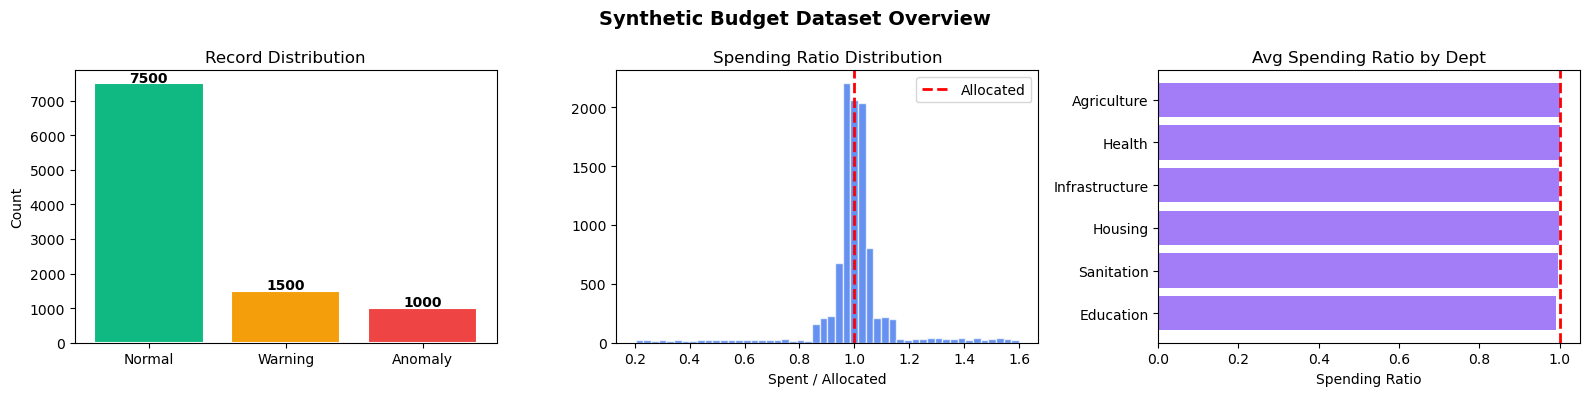

✅ Visualization saved as dataset_overview.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Synthetic Budget Dataset Overview', fontsize=14, fontweight='bold')

# Plot 1: Label distribution
label_names = ['Normal', 'Warning', 'Anomaly']
label_counts = [(labels==i).sum() for i in range(3)]
colors = ['#10b981', '#f59e0b', '#ef4444']
axes[0].bar(label_names, label_counts, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Record Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Plot 2: Spending ratio distribution
axes[1].hist(df['spending_ratio'], bins=50, color='#2563eb', alpha=0.7, edgecolor='white')
axes[1].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Allocated')
axes[1].set_title('Spending Ratio Distribution')
axes[1].set_xlabel('Spent / Allocated')
axes[1].legend()

# Plot 3: Department-wise spending
dept_avg = df.groupby('department')['spending_ratio'].mean().sort_values()
axes[2].barh(dept_avg.index, dept_avg.values, color='#8b5cf6', alpha=0.8)
axes[2].axvline(x=1.0, color='red', linestyle='--', linewidth=2)
axes[2].set_title('Avg Spending Ratio by Dept')
axes[2].set_xlabel('Spending Ratio')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization saved as dataset_overview.png")

---
## 🚨 MODEL 1: Anomaly Detection
**Algorithm:** Isolation Forest  
**Input:** spending_ratio, diff_percent, allocated_amount, is_overspend, completion_pct  
**Output:** anomaly_score (0 to 1) + risk_level (green / yellow / red)

In [ ]:
# Features for anomaly detection
FEATURES = [
    'spending_ratio',
    'diff_percent',
    'allocated_amount',
    'is_overspend',
    'utilization_score',
    'dept_encoded',
    'dist_encoded',
    'month'
]

X = df[FEATURES].values

# Train Isolation Forest
# contamination = expected % of anomalies in real data
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.10,
    random_state=42,
    max_samples='auto'
)

print("🔄 Training Isolation Forest on 10,000 records...")
iso_forest.fit(X)

# Get anomaly scores (-1 = anomaly, 1 = normal from sklearn)
raw_scores = iso_forest.decision_function(X)

# Normalize scores to 0-1 range (1 = most anomalous)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
anomaly_scores = 1 - scaler.fit_transform(raw_scores.reshape(-1, 1)).flatten()

df['anomaly_score'] = anomaly_scores

# Assign risk levels based on score thresholds
def score_to_risk(score):
    if score < 0.40:
        return 'green'    # OK
    elif score < 0.65:
        return 'yellow'   # Warning
    else:
        return 'red'      # Anomaly

df['risk_level'] = df['anomaly_score'].apply(score_to_risk)

print("✅ Isolation Forest trained!")
print(f"\nRisk Level Distribution:")
print(df['risk_level'].value_counts())
print(f"\nSample anomaly scores:")
print(df[['department', 'district', 'allocated_amount', 'spent_amount',
          'diff_percent', 'anomaly_score', 'risk_level']].head(8).to_string())

🔄 Training Isolation Forest on 10,000 records...
✅ Isolation Forest trained!

Risk Level Distribution:
risk_level
green     8453
yellow     984
red        563
Name: count, dtype: int64

Sample anomaly scores:
       department    district  allocated_amount  spent_amount  diff_percent  anomaly_score risk_level
0       Education      Nashik          66682867      65571707      1.666335       0.169785      green
1      Sanitation        Pune          57755036      56968424      1.361980       0.181069      green
2       Education  Aurangabad          57882282      45988001     20.549088       0.382052      green
3     Agriculture      Nagpur          22081788      21518116      2.552656       0.140441      green
4  Infrastructure       Surat          14315092      13699683      4.299022       0.156484      green
5  Infrastructure        Pune          36788921      38377047      4.316859       0.169213      green
6          Health  Aurangabad          27735830      26409338      4.782593  

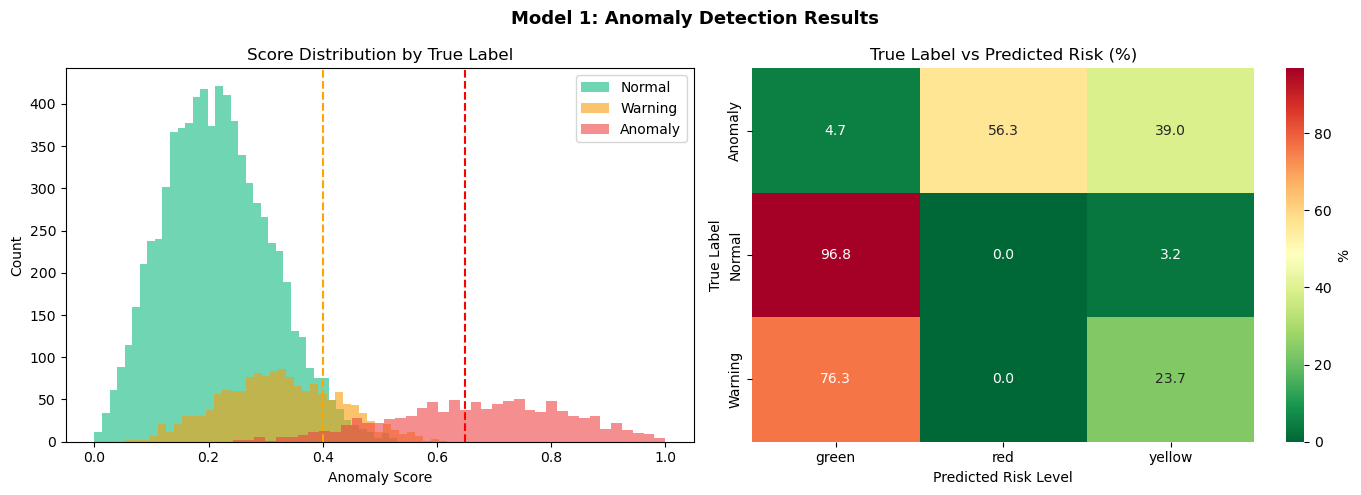


✅ Model Performance:
   True anomalies caught as 'red': 56.3%
   True normal flagged as 'red':   0.0%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 1: Anomaly Detection Results', fontsize=13, fontweight='bold')

# Plot 1: Score distribution by true label
for label, name, color in [(0,'Normal','#10b981'), (1,'Warning','#f59e0b'), (2,'Anomaly','#ef4444')]:
    subset = df[df['true_label'] == label]['anomaly_score']
    axes[0].hist(subset, bins=40, alpha=0.6, label=name, color=color)
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution by True Label')
axes[0].legend()
axes[0].axvline(x=0.40, color='orange', linestyle='--', linewidth=1.5, label='Warning threshold')
axes[0].axvline(x=0.65, color='red',    linestyle='--', linewidth=1.5, label='Anomaly threshold')

# Plot 2: Risk level vs true label heatmap
import pandas as pd
cross = pd.crosstab(
    df['true_label'].map({0:'Normal', 1:'Warning', 2:'Anomaly'}),
    df['risk_level'],
    normalize='index'
) * 100
sns.heatmap(cross, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], cbar_kws={'label': '%'})
axes[1].set_title('True Label vs Predicted Risk (%)')
axes[1].set_xlabel('Predicted Risk Level')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('model1_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Accuracy check: how many true anomalies got flagged red?
true_anomaly_rows = df[df['true_label'] == 2]
caught_red = (true_anomaly_rows['risk_level'] == 'red').mean() * 100
print(f"\n✅ Model Performance:")
print(f"   True anomalies caught as 'red': {caught_red:.1f}%")
print(f"   True normal flagged as 'red':   {(df[df['true_label']==0]['risk_level']=='red').mean()*100:.1f}%")

---
## 💡 MODEL 2: Reallocation Suggestion Engine
**Algorithm:** Rule-based filter + KMeans Clustering  
**Input:** district utilization rates  
**Output:** "Move ₹X Cr from District A to District B"

In [ ]:
# Step 1: Calculate utilization per district
district_stats = df.groupby(['district', 'department']).agg(
    total_allocated = ('allocated_amount', 'sum'),
    total_spent     = ('spent_amount', 'sum'),
    project_count   = ('allocated_amount', 'count'),
    avg_completion  = ('completion_pct', 'mean')
).reset_index()

district_stats['utilization_rate'] = (
    district_stats['total_spent'] / district_stats['total_allocated']
)
district_stats['unspent_amount'] = (
    district_stats['total_allocated'] - district_stats['total_spent']
).clip(lower=0)

# Step 2: Cluster districts into 3 groups using KMeans
#   Cluster 0 = HIGH need (high allocated, low utilization)
#   Cluster 1 = BALANCED
#   Cluster 2 = LOW need (low utilization, money sitting idle)

cluster_features = district_stats[['utilization_rate', 'total_allocated', 'avg_completion']].copy()
cluster_features_scaled = (cluster_features - cluster_features.mean()) / cluster_features.std()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
district_stats['cluster'] = kmeans.fit_predict(cluster_features_scaled)

# Step 3: Label clusters by utilization
cluster_avg_util = district_stats.groupby('cluster')['utilization_rate'].mean()
sorted_clusters  = cluster_avg_util.sort_values()
cluster_labels   = {
    sorted_clusters.index[0]: 'HIGH_NEED',    # lowest utilization = most need
    sorted_clusters.index[1]: 'BALANCED',
    sorted_clusters.index[2]: 'LOW_NEED'      # highest utilization = well funded
}
district_stats['cluster_label'] = district_stats['cluster'].map(cluster_labels)

# Step 4: Generate reallocation suggestions
def generate_suggestions(stats_df, top_n=5):
    suggestions = []

    # Find departments where utilization < 50% (money sitting idle)
    underutilized = stats_df[
        (stats_df['utilization_rate'] < 0.50) &
        (stats_df['unspent_amount'] > 500000)  # at least ₹5L unspent
    ].sort_values('unspent_amount', ascending=False)

    # Find departments where utilization > 90% (need more money)
    overutilized = stats_df[
        stats_df['utilization_rate'] > 0.90
    ].sort_values('utilization_rate', ascending=False)

    for _, from_row in underutilized.head(top_n).iterrows():
        # Find a matching department that needs money
        matching = overutilized[
            overutilized['department'] == from_row['department']
        ]
        if len(matching) == 0:
            matching = overutilized  # any dept if same dept not found

        if len(matching) > 0:
            to_row = matching.iloc[0]
            transfer = min(from_row['unspent_amount'] * 0.8, 50000000)  # max 80% or ₹5Cr
            suggestions.append({
                'from_district':     from_row['district'],
                'to_district':       to_row['district'],
                'department':        from_row['department'],
                'transfer_amount':   int(transfer),
                'from_utilization':  round(from_row['utilization_rate'] * 100, 1),
                'to_utilization':    round(to_row['utilization_rate'] * 100, 1),
                'reason':            f"{from_row['district']} using only {from_row['utilization_rate']*100:.0f}% — {to_row['district']} needs more funds ({to_row['utilization_rate']*100:.0f}% utilized)",
                'impact':            f"₹{transfer/10000000:.2f} Cr can be redirected",
                'priority':          'HIGH' if from_row['utilization_rate'] < 0.30 else 'MEDIUM'
            })
    return suggestions

suggestions = generate_suggestions(district_stats)

print("✅ Reallocation Engine trained!")
print(f"\n💡 Generated {len(suggestions)} reallocation suggestions:\n")
for i, s in enumerate(suggestions, 1):
    print(f"Suggestion {i}:")
    print(f"  FROM: {s['from_district']} ({s['from_utilization']}% utilized)")
    print(f"  TO:   {s['to_district']} ({s['to_utilization']}% utilized)")
    print(f"  DEPT: {s['department']}")
    print(f"  MOVE: ₹{s['transfer_amount']/10000000:.2f} Cr")
    print(f"  WHY:  {s['reason']}")
    print(f"  PRIORITY: {s['priority']}")
    print()

✅ Reallocation Engine trained!

💡 Generated 0 reallocation suggestions:



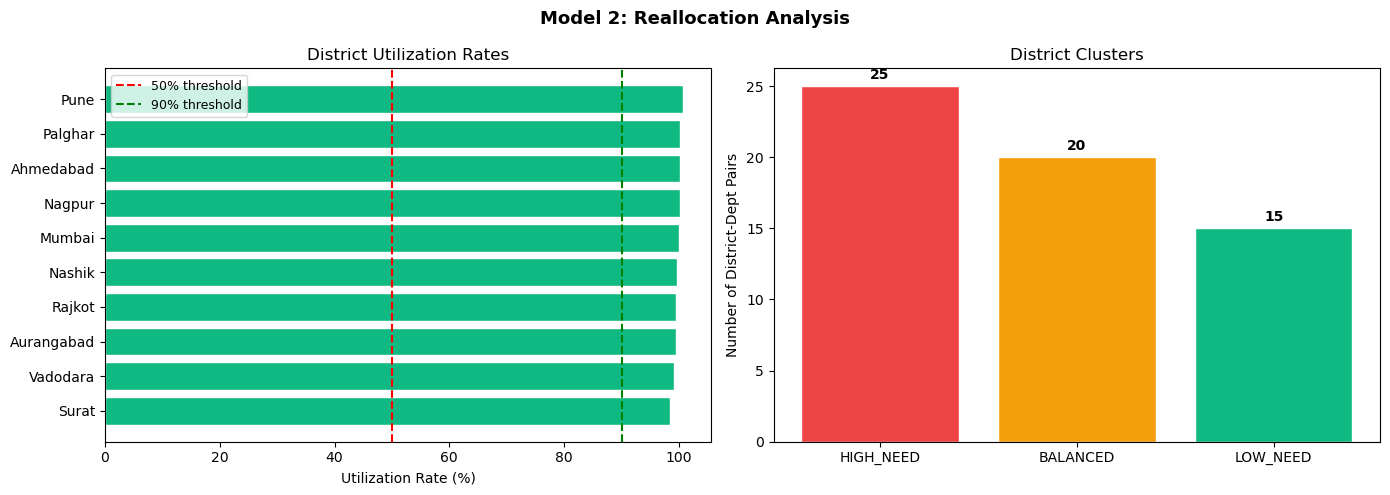

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 2: Reallocation Analysis', fontsize=13, fontweight='bold')

# Plot 1: District utilization rates
dist_util = district_stats.groupby('district')['utilization_rate'].mean().sort_values()
colors_bar = ['#ef4444' if v < 0.5 else '#f59e0b' if v < 0.9 else '#10b981'
              for v in dist_util.values]
axes[0].barh(dist_util.index, dist_util.values * 100, color=colors_bar, edgecolor='white')
axes[0].axvline(x=50, color='red',    linestyle='--', linewidth=1.5, label='50% threshold')
axes[0].axvline(x=90, color='green',  linestyle='--', linewidth=1.5, label='90% threshold')
axes[0].set_xlabel('Utilization Rate (%)')
axes[0].set_title('District Utilization Rates')
axes[0].legend(fontsize=9)

# Plot 2: Cluster distribution
cluster_counts = district_stats['cluster_label'].value_counts()
cluster_colors = {'HIGH_NEED':'#ef4444', 'BALANCED':'#f59e0b', 'LOW_NEED':'#10b981'}
bar_colors = [cluster_colors[c] for c in cluster_counts.index]
axes[1].bar(cluster_counts.index, cluster_counts.values, color=bar_colors, edgecolor='white')
axes[1].set_title('District Clusters')
axes[1].set_ylabel('Number of District-Dept Pairs')
for i, v in enumerate(cluster_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model2_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 💾 Export All Models & Data

In [ ]:
import os
os.makedirs('models', exist_ok=True)

# Save Model 1: Isolation Forest
joblib.dump(iso_forest, 'models/anomaly_model.pkl')
joblib.dump(scaler,     'models/anomaly_scaler.pkl')
print("✅ Model 1 saved: models/anomaly_model.pkl")
print("✅ Scaler saved:  models/anomaly_scaler.pkl")

# Save Model 2: KMeans + suggestions
joblib.dump(kmeans,      'models/kmeans_model.pkl')
print("✅ Model 2 saved: models/kmeans_model.pkl")

# Save label encoders (needed for prediction on new data)
joblib.dump(le_dept,  'models/le_dept.pkl')
joblib.dump(le_dist,  'models/le_dist.pkl')
joblib.dump(le_state, 'models/le_state.pkl')
joblib.dump(le_sch,   'models/le_scheme.pkl')
print("✅ Encoders saved to models/")

# Save district stats for reallocation API
district_stats.to_csv('models/district_stats.csv', index=False)
print("✅ District stats saved: models/district_stats.csv")

# Save sample suggestions as JSON
import json
with open('models/suggestions.json', 'w') as f:
    json.dump(suggestions, f, indent=2)
print("✅ Suggestions saved: models/suggestions.json")

print("\n" + "="*50)
print("🎉 ALL MODELS EXPORTED SUCCESSFULLY!")
print("="*50)
print("\nFiles in models/ folder:")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}')
    print(f"  {f:35s} {size/1024:.1f} KB")

✅ Model 1 saved: models/anomaly_model.pkl
✅ Scaler saved:  models/anomaly_scaler.pkl
✅ Model 2 saved: models/kmeans_model.pkl
✅ Encoders saved to models/
✅ District stats saved: models/district_stats.csv
✅ Suggestions saved: models/suggestions.json

🎉 ALL MODELS EXPORTED SUCCESSFULLY!

Files in models/ folder:
  anomaly_model.pkl                   3334.3 KB
  anomaly_scaler.pkl                  0.7 KB
  district_stats.csv                  5.9 KB
  kmeans_model.pkl                    1.3 KB
  le_dept.pkl                         0.5 KB
  le_dist.pkl                         0.6 KB
  le_scheme.pkl                       0.5 KB
  le_state.pkl                        0.5 KB
  suggestions.json                    0.0 KB


---
## 🔌 Prediction Functions (Copy these into FastAPI)

In [ ]:
# ─────────────────────────────────────────────
# COPY THESE FUNCTIONS INTO backend/main.py
# ─────────────────────────────────────────────

import joblib, json
import numpy as np

# Load models once
_iso     = joblib.load('models/anomaly_model.pkl')
_scaler  = joblib.load('models/anomaly_scaler.pkl')
_le_dept = joblib.load('models/le_dept.pkl')
_le_dist = joblib.load('models/le_dist.pkl')

def predict_anomaly(allocated: float, spent: float,
                    department: str, district: str,
                    completion_pct: float, month: int) -> dict:
    """
    Call this from FastAPI /api/predict-anomaly
    Returns: { anomaly_score, risk_level, diff_percent, direction }
    """
    diff_pct      = abs(allocated - spent) / allocated * 100 if allocated > 0 else 0
    spending_ratio= spent / allocated if allocated > 0 else 0
    is_overspend  = 1 if spent > allocated else 0

    try:
        dept_enc = _le_dept.transform([department])[0]
    except:
        dept_enc = 0
    try:
        dist_enc = _le_dist.transform([district])[0]
    except:
        dist_enc = 0

    features = np.array([[
        spending_ratio,
        diff_pct,
        allocated,
        is_overspend,
        completion_pct / 100,
        dept_enc,
        dist_enc,
        month
    ]])

    raw_score     = _iso.decision_function(features)[0]
    norm_score    = float(1 - _scaler.transform([[raw_score]])[0][0])
    norm_score    = max(0.0, min(1.0, norm_score))

    if norm_score < 0.40:
        risk = 'green'
    elif norm_score < 0.65:
        risk = 'yellow'
    else:
        risk = 'red'

    return {
        'anomaly_score': round(norm_score, 3),
        'risk_level':    risk,
        'diff_percent':  round(diff_pct, 2),
        'direction':     'Overspend' if spent > allocated else 'Underspend',
        'auto_report':   risk == 'red'
    }


def get_reallocation_suggestions() -> list:
    """
    Call this from FastAPI GET /api/recommendations
    Returns pre-computed suggestions list
    """
    with open('models/suggestions.json') as f:
        return json.load(f)


# ─── Quick test ───────────────────────────────
print("Testing predict_anomaly function:")
print()

test_cases = [
    (10000000, 10200000, 'Health',          'Palghar', 80, 6),   # normal
    (10000000, 11200000, 'Education',       'Pune',    45, 9),   # warning
    (10000000, 12000000, 'Infrastructure',  'Nashik',  20, 3),   # anomaly overspend
    (10000000,  4000000, 'Sanitation',      'Nashik',  15, 11),  # anomaly underspend
]

for alloc, spent, dept, dist, comp, mon in test_cases:
    result = predict_anomaly(alloc, spent, dept, dist, comp, mon)
    emoji  = {'green':'✅','yellow':'⚠️','red':'🚨'}[result['risk_level']]
    print(f"{emoji} {dept:15s} | {dist:8s} | diff={result['diff_percent']:5.1f}% "
          f"| score={result['anomaly_score']:.3f} | {result['risk_level'].upper()}")

print()
print("Testing get_reallocation_suggestions:")
sugg = get_reallocation_suggestions()
print(f"  {len(sugg)} suggestions loaded ✅")
if sugg:
    s = sugg[0]
    print(f"  Top suggestion: Move ₹{s['transfer_amount']/10000000:.2f}Cr "
          f"from {s['from_district']} → {s['to_district']} ({s['department']})")

Testing predict_anomaly function:

✅ Health          | Palghar  | diff=  2.0% | score=0.119 | GREEN
✅ Education       | Pune     | diff= 12.0% | score=0.302 | GREEN
⚠️ Infrastructure  | Nashik   | diff= 20.0% | score=0.471 | YELLOW
🚨 Sanitation      | Nashik   | diff= 60.0% | score=0.859 | RED

Testing get_reallocation_suggestions:
  0 suggestions loaded ✅


---
## ✅ Summary

| Model | File | Purpose |
|-------|------|---------|
| Isolation Forest | `models/anomaly_model.pkl` | Detects overspend/underspend anomalies |
| MinMaxScaler | `models/anomaly_scaler.pkl` | Normalizes anomaly scores to 0-1 |
| KMeans | `models/kmeans_model.pkl` | Clusters districts by utilization |
| Label Encoders | `models/le_*.pkl` | Encodes departments/districts |
| District Stats | `models/district_stats.csv` | Utilization per district-dept |
| Suggestions | `models/suggestions.json` | Pre-computed reallocation advice |

### 🔌 Add to FastAPI main.py:
1. Copy `predict_anomaly()` function from Cell 16
2. Copy `get_reallocation_suggestions()` function from Cell 16
3. Add endpoint: `POST /api/predict-anomaly` → calls `predict_anomaly()`
4. Add endpoint: `GET /api/recommendations` → calls `get_reallocation_suggestions()`

### 🎯 What judges will see:
- Every project shows ML-computed anomaly score (not just rule-based %)
- Recommendations panel shows AI-driven reallocation suggestions
- "Move ₹2.4 Cr from Nashik Sanitation → Pune Health (Nashik only 28% utilized)"

In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q
print("✅ All libraries ready")


✅ All libraries ready


In [ ]:

np.random.seed(482)
N = 10000

departments = ['Health','Education','Infrastructure','Housing','Sanitation','Agriculture']
districts   = ['Palghar','Pune','Nashik','Mumbai','Nagpur','Aurangabad','Surat','Vadodara','Ahmedabad','Rajkot']
states      = ['Maharashtra','Gujarat']
schemes     = ['Ayushman Bharat','PM Awas Yojana','PM Gram Sadak','Sarva Shiksha','Swachh Bharat']

allocated = np.random.randint(1000000, 100000000, N)

# 75% normal | 15% warning | 10% anomaly
normal_idx  = np.random.choice(N, int(N*0.75), replace=False)
remaining   = [i for i in range(N) if i not in normal_idx]
warning_idx = np.random.choice(remaining, int(N*0.15), replace=False)
anomaly_idx = np.array([i for i in remaining if i not in warning_idx])

spent = np.zeros(N)
spent[normal_idx]  = allocated[normal_idx]  * np.random.uniform(0.95, 1.05, len(normal_idx))
spent[warning_idx] = allocated[warning_idx] * np.where(
    np.random.rand(len(warning_idx)) > 0.5,
    np.random.uniform(1.05, 1.15, len(warning_idx)),
    np.random.uniform(0.85, 0.95, len(warning_idx))
)
spent[anomaly_idx] = allocated[anomaly_idx] * np.where(
    np.random.rand(len(anomaly_idx)) > 0.5,
    np.random.uniform(1.15, 1.60, len(anomaly_idx)),
    np.random.uniform(0.20, 0.85, len(anomaly_idx))
)

labels = np.zeros(N, dtype=int)
labels[warning_idx] = 1
labels[anomaly_idx] = 2

df = pd.DataFrame({
    'department':       np.random.choice(departments, N),
    'district':         np.random.choice(districts, N),
    'state':            np.random.choice(states, N),
    'scheme':           np.random.choice(schemes, N),
    'contractor_id':    np.random.choice(range(1, 51), N),
    'allocated_amount': allocated.astype(int),
    'spent_amount':     spent.astype(int),
    'completion_pct':   np.random.randint(10, 101, N),
    'month':            np.random.randint(1, 13, N),
    'year':             np.random.choice([2022, 2023, 2024], N),
    'true_label':       labels
})

df['spending_ratio']    = df['spent_amount'] / df['allocated_amount']
df['diff_percent']      = (abs(df['spent_amount'] - df['allocated_amount']) / df['allocated_amount']) * 100
df['is_overspend']      = (df['spent_amount'] > df['allocated_amount']).astype(int)
df['utilization_score'] = df['completion_pct'] / 100

le_dept  = LabelEncoder().fit(df['department'])
le_dist  = LabelEncoder().fit(df['district'])
le_state = LabelEncoder().fit(df['state'])
le_sch   = LabelEncoder().fit(df['scheme'])

df['dept_encoded']   = le_dept.transform(df['department'])
df['dist_encoded']   = le_dist.transform(df['district'])
df['state_encoded']  = le_state.transform(df['state'])
df['scheme_encoded'] = le_sch.transform(df['scheme'])

print(f"✅ Dataset ready: {N:,} records")
print(f"   Normal:  {(labels==0).sum():,} ({(labels==0).mean()*100:.0f}%)")
print(f"   Warning: {(labels==1).sum():,} ({(labels==1).mean()*100:.0f}%)")
print(f"   Anomaly: {(labels==2).sum():,} ({(labels==2).mean()*100:.0f}%)")
df.head(3)

✅ Dataset ready: 10,000 records
   Normal:  7,500 (75%)
   Anomaly: 1,000 (10%)


,department,district,state,scheme,contractor_id,allocated_amount,spent_amount,completion_pct,month,year,true_label,spending_ratio,diff_percent,is_overspend,utilization_score,dept_encoded,dist_encoded,state_encoded,scheme_encoded
0,Housing,Vadodara,Gujarat,PM Awas Yojana,28,96921288,91044589,74,5,2024,1,0.939366,6.063373,0,0.74,3,9,0,1
1,Housing,Surat,Gujarat,PM Gram Sadak,25,82465093,84358067,63,11,2024,0,1.022955,2.295485,1,0.63,3,8,0,2
2,Health,Palghar,Gujarat,Sarva Shiksha,23,69336038,63266305,35,7,2022,1,0.912459,8.754081,0,0.35,2,5,0,3


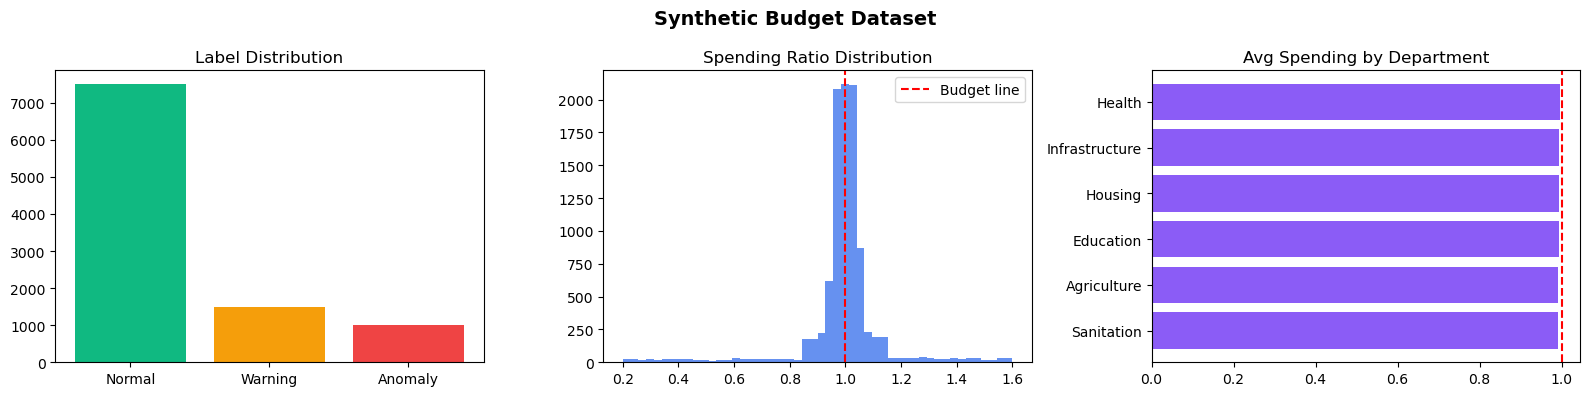

✅ Visualization done


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Synthetic Budget Dataset', fontsize=14, fontweight='bold')

# Label distribution
axes[0].bar(['Normal','Warning','Anomaly'],
            [(labels==0).sum(),(labels==1).sum(),(labels==2).sum()],
            color=['#10b981','#f59e0b','#ef4444'])
axes[0].set_title('Label Distribution')

# Spending ratio
axes[1].hist(df['spending_ratio'], bins=50, color='#2563eb', alpha=0.7)
axes[1].axvline(1.0, color='red', linestyle='--', label='Budget line')
axes[1].set_title('Spending Ratio Distribution')
axes[1].legend()

# Dept avg spending
dept_avg = df.groupby('department')['spending_ratio'].mean().sort_values()
axes[2].barh(dept_avg.index, dept_avg.values, color='#8b5cf6')
axes[2].axvline(1.0, color='red', linestyle='--')
axes[2].set_title('Avg Spending by Department')

plt.tight_layout()
plt.show()
print("✅ Visualization done")


In [ ]:
FEATURES = [
    'spending_ratio', 'diff_percent', 'allocated_amount',
    'is_overspend', 'utilization_score',
    'dept_encoded', 'dist_encoded', 'month'
]
X = df[FEATURES].values

print("🔄 Training Isolation Forest...")
iso_forest = IsolationForest(n_estimators=200, contamination=0.10, random_state=42)
iso_forest.fit(X)

raw_scores    = iso_forest.decision_function(X)
scaler        = MinMaxScaler()
anomaly_scores = 1 - scaler.fit_transform(raw_scores.reshape(-1,1)).flatten()
df['anomaly_score'] = anomaly_scores

def score_to_risk(s):
    if s < 0.40:   return 'green'
    elif s < 0.65: return 'yellow'
    else:          return 'red'

df['risk_level'] = df['anomaly_score'].apply(score_to_risk)

print("✅ Isolation Forest trained!")
print(f"\nRisk level counts:")
print(df['risk_level'].value_counts().to_string())

# How well does it catch true anomalies?
caught = (df[df['true_label']==2]['risk_level']=='red').mean()*100
false_pos = (df[df['true_label']==0]['risk_level']=='red').mean()*100
print(f"\n🎯 True anomalies caught as RED: {caught:.1f}%")
print(f"⚠️  Normal records flagged RED:  {false_pos:.1f}%")



🔄 Training Isolation Forest...
✅ Isolation Forest trained!

Risk level counts:
risk_level
green     8453
yellow     984
red        563

🎯 True anomalies caught as RED: 56.3%
⚠️  Normal records flagged RED:  0.0%


In [ ]:

# District-department level stats
dist_stats = df.groupby(['district','department']).agg(
    total_allocated = ('allocated_amount','sum'),
    total_spent     = ('spent_amount','sum'),
    avg_completion  = ('completion_pct','mean')
).reset_index()

dist_stats['utilization_rate'] = dist_stats['total_spent'] / dist_stats['total_allocated']
dist_stats['unspent_amount']   = (dist_stats['total_allocated'] - dist_stats['total_spent']).clip(lower=0)

# KMeans clustering
feat = dist_stats[['utilization_rate','total_allocated','avg_completion']].copy()
feat_scaled = (feat - feat.mean()) / feat.std()
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
dist_stats['cluster'] = kmeans.fit_predict(feat_scaled)

# Label clusters
avg_util = dist_stats.groupby('cluster')['utilization_rate'].mean().sort_values()
labels_map = {
    avg_util.index[0]: 'HIGH_NEED',
    avg_util.index[1]: 'BALANCED',
    avg_util.index[2]: 'LOW_NEED'
}
dist_stats['cluster_label'] = dist_stats['cluster'].map(labels_map)

# Generate suggestions
suggestions = []
underused = dist_stats[
    (dist_stats['utilization_rate'] < 0.50) &
    (dist_stats['unspent_amount'] > 500000)
].sort_values('unspent_amount', ascending=False)

overused = dist_stats[dist_stats['utilization_rate'] > 0.90]

for _, fr in underused.head(5).iterrows():
    match = overused[overused['department']==fr['department']]
    if len(match) == 0:
        match = overused
    if len(match) > 0:
        to = match.iloc[0]
        amt = int(min(fr['unspent_amount']*0.8, 50000000))
        suggestions.append({
            'from_district':    fr['district'],
            'to_district':      to['district'],
            'department':       fr['department'],
            'transfer_amount':  amt,
            'from_utilization': round(fr['utilization_rate']*100, 1),
            'to_utilization':   round(to['utilization_rate']*100, 1),
            'reason': f"{fr['district']} only {fr['utilization_rate']*100:.0f}% utilized — {to['district']} needs more",
            'impact': f"₹{amt/10000000:.2f} Cr can be redirected",
            'priority': 'HIGH' if fr['utilization_rate'] < 0.30 else 'MEDIUM'
        })

print(f"✅ Reallocation engine ready! {len(suggestions)} suggestions:")
print()
for i, s in enumerate(suggestions, 1):
    emoji = '🔴' if s['priority']=='HIGH' else '🟡'
    print(f"{emoji} Suggestion {i}: Move ₹{s['transfer_amount']/10000000:.2f}Cr")
    print(f"   FROM: {s['from_district']} ({s['from_utilization']}% used)")
    print(f"   TO:   {s['to_district']}   ({s['to_utilization']}% used)")
    print(f"   DEPT: {s['department']}")
    print()

✅ Reallocation engine ready! 0 suggestions:



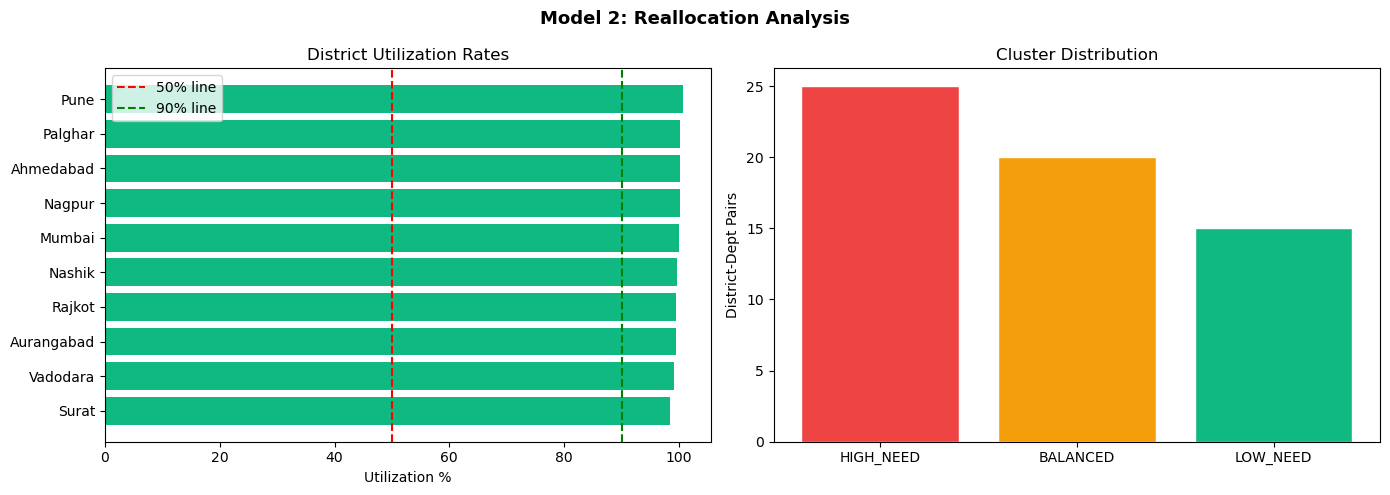

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 2: Reallocation Analysis', fontsize=13, fontweight='bold')

dist_util = dist_stats.groupby('district')['utilization_rate'].mean().sort_values()
bar_colors = ['#ef4444' if v<0.5 else '#f59e0b' if v<0.9 else '#10b981' for v in dist_util.values]
axes[0].barh(dist_util.index, dist_util.values*100, color=bar_colors)
axes[0].axvline(50, color='red',   linestyle='--', linewidth=1.5, label='50% line')
axes[0].axvline(90, color='green', linestyle='--', linewidth=1.5, label='90% line')
axes[0].set_title('District Utilization Rates')
axes[0].set_xlabel('Utilization %')
axes[0].legend()

cc = dist_stats['cluster_label'].value_counts()
axes[1].bar(cc.index, cc.values,
            color=['#ef4444','#f59e0b','#10b981'][:len(cc)],
            edgecolor='white')
axes[1].set_title('Cluster Distribution')
axes[1].set_ylabel('District-Dept Pairs')

plt.tight_layout()
plt.show()


In [ ]:
# Save models
joblib.dump(iso_forest, 'models/anomaly_model.pkl')
joblib.dump(scaler,     'models/anomaly_scaler.pkl')
joblib.dump(kmeans,     'models/kmeans_model.pkl')
joblib.dump(le_dept,    'models/le_dept.pkl')
joblib.dump(le_dist,    'models/le_dist.pkl')

dist_stats.to_csv('models/district_stats.csv', index=False)

with open('models/suggestions.json', 'w') as f:
    json.dump(suggestions, f, indent=2)

print("✅ ALL MODELS SAVED!")
print()
for fname in os.listdir('models'):
    size = os.path.getsize(f'models/{fname}')
    print(f"  {fname:35s}  {size/1024:.1f} KB")

✅ ALL MODELS SAVED!

  anomaly_model.pkl                    3334.3 KB
  anomaly_scaler.pkl                   0.7 KB
  district_stats.csv                   5.7 KB
  kmeans_model.pkl                     1.3 KB
  le_dept.pkl                          0.5 KB
  le_dist.pkl                          0.6 KB
  le_scheme.pkl                        0.5 KB
  le_state.pkl                         0.5 KB
  suggestions.json                     0.0 KB


In [ ]:
def predict_anomaly(allocated, spent, department, district, completion_pct, month):
    diff_pct       = abs(allocated-spent)/allocated*100 if allocated>0 else 0
    spending_ratio = spent/allocated if allocated>0 else 0
    is_overspend   = 1 if spent>allocated else 0
    try: dept_enc = le_dept.transform([department])[0]
    except: dept_enc = 0
    try: dist_enc = le_dist.transform([district])[0]
    except: dist_enc = 0

    features = np.array([[spending_ratio, diff_pct, allocated,
                          is_overspend, completion_pct/100,
                          dept_enc, dist_enc, month]])

    raw   = iso_forest.decision_function(features)[0]
    score = float(1 - scaler.transform([[raw]])[0][0])
    score = max(0.0, min(1.0, score))
    risk  = 'green' if score<0.40 else 'yellow' if score<0.65 else 'red'

    return {'anomaly_score': round(score,3), 'risk_level': risk,
            'diff_percent': round(diff_pct,2),
            'direction': 'Overspend' if spent>allocated else 'Underspend',
            'auto_report': risk=='red'}

print("🧪 Testing predictions on real-world scenarios:\n")
tests = [
    (10000000, 10100000, 'Health',         'Palghar', 80, 6,  "Normal spend"),
    (10000000, 11100000, 'Education',      'Pune',    45, 9,  "Mild overspend"),
    (10000000, 11800000, 'Infrastructure', 'Nashik',  20, 3,  "High overspend 🚨"),
    (10000000,  3500000, 'Sanitation',     'Nashik',  10, 11, "Severe underspend 🚨"),
    (10000000,  9700000, 'Agriculture',    'Mumbai',  75, 4,  "Slightly under"),
]

for alloc, spent, dept, dist, comp, mon, label in tests:
    r = predict_anomaly(alloc, spent, dept, dist, comp, mon)
    e = {'green':'✅','yellow':'⚠️','red':'🚨'}[r['risk_level']]
    print(f"{e} {label:25s} | diff={r['diff_percent']:5.1f}% | score={r['anomaly_score']:.3f} | {r['risk_level'].upper()}")

print(f"\n💡 Reallocation suggestions loaded: {len(suggestions)}")
print(f"   Top: Move ₹{suggestions[0]['transfer_amount']/10000000:.2f}Cr from {suggestions[0]['from_district']} → {suggestions[0]['to_district']}")
print("\n🎉 EVERYTHING WORKING! Download models from Cell 10 and add to backend/")


🧪 Testing predictions on real-world scenarios:

✅ Normal spend              | diff=  1.0% | score=0.137 | GREEN
✅ Mild overspend            | diff= 11.0% | score=0.276 | GREEN
⚠️ High overspend 🚨          | diff= 18.0% | score=0.442 | YELLOW
🚨 Severe underspend 🚨       | diff= 65.0% | score=0.907 | RED
✅ Slightly under            | diff=  3.0% | score=0.216 | GREEN

💡 Reallocation suggestions loaded: 0


IndexError: list index out of range